# Homework 5 Guide

1. Save a copy of this `.ipynb` file to your Google Drive or PC.  
2. Rename the file from **`HW5.ipynb`** to **`HW5_(your name).ipynb`**.  
3. Complete the code cells below by following the given instructions.  
4. Save your work and upload the `.ipynb` file to Canvas.  
   - Do **NOT** clear the outputs; leave your results visible.  
5. ⚠️ **IMPORTANT**: Convert your `.ipynb` file to a `.PDF` and upload them **together**.
    - Go to the top menu → **File → Print → Save as PDF**.  

.

.

# [HW 5] Customize the MLP

1. Load `FeatureData.csv` (NOT `FeatureSelected`) saved from DA3_Code1.

2. Conduct the **t-Test** and select 30 features with the *LARGEST P-VALUE*.

3. Create labels and prepare `TrainData`, `TestData`, `TrainLabel`, and `TestLable`. (Test ratio = 20%)

4. Design and train a customized MLP model with the following settings:

- Learning rate: `0.01`.
- Number of hidden layers: `3`.
- Neurons in the first hidden layer: `15`.
- Neurons in the second hidden layer: `10`.
- Neurons in the third hidden layer: `5`.
- Training epochs: `300`.
- Use a different **activation function** from ML1_Code1 (refer to the provided link in ML1; if a function is incompatible, try another).  
- Use a different **loss function** and **optimization algorithm** from ML1_Code1 (refer to the provided link in ML1; if incompatible, try alternatives).

5. Plot the training process (**Loss**, **Accuracy**).  

6. Plot a confusion matrix for the test data evaluation.

7. Print `Accuracy`, `Recall`, `Precision`, and `F1-score` of test data evaluation.

In [1]:
# Import basic packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mount your google drive
from google.colab import drive
drive.mount('/content/drive')

# Import the 'Tensorflow' pakage
import tensorflow as tf
from tensorflow import keras

# Check the version of tensorflow
print(tf.__version__)

Mounted at /content/drive
2.21.0


In [2]:
from sklearn.preprocessing import StandardScaler

# Load feature data (270) and P-values
FeatureData = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SavedFiles/FeatureData.csv', header=None)
P_value_Rank = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SavedFiles/P_value_Rank.csv' , header=None)

# Select the 30 features that are most difficult to distinguish (with the highest p-value)
StartRank, Number = 241, 30
FeatureSelected = np.zeros((Number,FeatureData.shape[1]))
s = 0
for i in range(StartRank, StartRank+Number):
    index                = int(P_value_Rank.iloc[i-1,0])
    FeatureSelected[s,:] = FeatureData.iloc[index,:].values
    s += 1

# Standardize the selected features
FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected.T)
FeatureSelected_std.shape

(360, 30)

In [3]:
# Number of data for each condition: 180
NoOfData   = int(FeatureSelected_std.shape[0]/2)

NormalSet   = FeatureSelected_std[:NoOfData , :]
AbnormalSet = FeatureSelected_std[NoOfData: , :]

NormalSet.shape, AbnormalSet.shape

((180, 30), (180, 30))

In [4]:
from sklearn.model_selection    import train_test_split

# Designate test data ratio
TestData_Ratio = 0.2

TrainData_Nor, TestData_Nor = train_test_split(NormalSet  , test_size=TestData_Ratio, random_state=777)
TrainData_Abn, TestData_Abn = train_test_split(AbnormalSet, test_size=TestData_Ratio, random_state=777)

print(TrainData_Nor.shape, TestData_Nor.shape)
print(TrainData_Abn.shape, TestData_Abn.shape)

(144, 30) (36, 30)
(144, 30) (36, 30)


In [5]:
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0],2))
TrainLabel_Abn = np.ones( (TrainData_Abn.shape[0],2))
TestLabel_Nor  = np.zeros((TestData_Nor.shape[0],2))
TestLabel_Abn  = np.ones( (TestData_Abn.shape[0],2))

TrainLabel_Nor[:,0] = 1  # [1,0]: Normal
TrainLabel_Abn[:,0] = 0  # [0,1]: Abnormal
TestLabel_Nor[:,0]  = 1  # [1,0]: Normal
TestLabel_Abn[:,0]  = 0  # [0,1]: Abnormal

print(TrainLabel_Nor.shape, TestLabel_Nor.shape)
print(TrainLabel_Abn.shape, TestLabel_Abn.shape)

(144, 2) (36, 2)
(144, 2) (36, 2)


In [6]:
TrainData  = np.concatenate([TrainData_Nor , TrainData_Abn ], axis=0)
TestData   = np.concatenate([TestData_Nor  , TestData_Abn  ], axis=0)
TrainLabel = np.concatenate([TrainLabel_Nor, TrainLabel_Abn], axis=0)
TestLabel  = np.concatenate([TestLabel_Nor , TestLabel_Abn ], axis=0)

print(TrainData.shape,  TestData.shape)
print(TrainLabel.shape, TestLabel.shape)

(288, 30) (72, 30)
(288, 2) (72, 2)


.

.

.

In [7]:
learningRate  = 0.01
Epoch         = 300

In [8]:
def MLP_model(input_data):
    keras.backend.clear_session() # clearing the Keras backend session (initiating variables)

    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape = (input_data.shape[1],) ))                                      # Input  Layer
    model.add(keras.layers.Dense(units = 15, activation = keras.activations.selu,    name = 'Hidden1'))    # Hidden Layer 1
    model.add(keras.layers.Dense(units = 10, activation = keras.activations.selu,    name = 'Hidden2'))    # Hidden Layer 2
    model.add(keras.layers.Dense(units = 5 , activation = keras.activations.selu,    name = 'Hidden3'))    # Hidden Layer 3
    model.add(keras.layers.Dense(units = 2,  activation = keras.activations.softmax, name = 'Output'))     # Output Layer

    model.compile(optimizer = keras.optimizers.AdamW(learning_rate = learningRate), # Optimization algorithm
                  loss = keras.losses.BinaryCrossentropy(),                   # Loss function (objective function of Optimization)
                  metrics = ['accuracy'])                                          # Metrics to measure during the training process
    return model

In [9]:
# Check the model architecture and the number of parameters
MLP = MLP_model(TrainData)
MLP.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden1 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden3 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692 (2.70 KB)

 Trainable params: 692 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Define the callback function
EpochForPrint = 20

class CheckProcess(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        keras.callbacks.Callback()
        if epoch%EpochForPrint == 0:
            print("{} Epochs Train Acc. : {:.2f}%  ".format(epoch, logs["accuracy"]*100))

In [12]:
hist = MLP.fit(TrainData, TrainLabel, epochs=Epoch, verbose=0, callbacks=[CheckProcess()])

print('Final Train Accuracy : {:.2f}%'.format(hist.history['accuracy'][-1]*100))

0 Epochs Train Acc. : 53.12%  
20 Epochs Train Acc. : 99.31%  
40 Epochs Train Acc. : 100.00%  
60 Epochs Train Acc. : 100.00%  
80 Epochs Train Acc. : 100.00%  
100 Epochs Train Acc. : 100.00%  
120 Epochs Train Acc. : 100.00%  
140 Epochs Train Acc. : 100.00%  
160 Epochs Train Acc. : 100.00%  
180 Epochs Train Acc. : 100.00%  
200 Epochs Train Acc. : 100.00%  
220 Epochs Train Acc. : 100.00%  
240 Epochs Train Acc. : 100.00%  
260 Epochs Train Acc. : 100.00%  
280 Epochs Train Acc. : 100.00%  
Final Train Accuracy : 100.00%


In [13]:
Loss, Accuracy = MLP.evaluate(TestData,  TestLabel, verbose=0)
Loss, Accuracy

(0.9482234120368958, 0.9027777910232544)

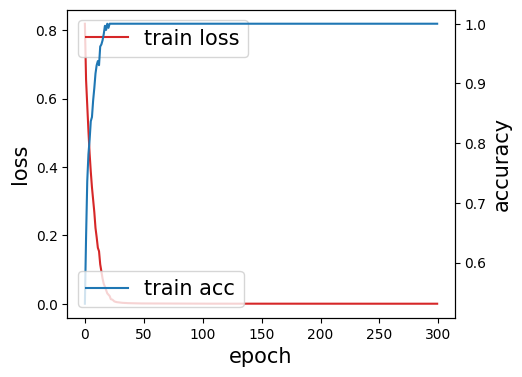

In [15]:
# Check the training process (Loss, Accuracy)

fig, loss_ax = plt.subplots(figsize=(5,4))
acc_ax = loss_ax.twinx()

loss_ax.plot(hist.history['loss'], label='train loss', c = 'tab:red')
loss_ax.set_xlabel('epoch', fontsize=15)
loss_ax.set_ylabel('loss', fontsize=15)
loss_ax.legend(loc='upper left', fontsize=15)

acc_ax.plot(hist.history['accuracy'], label='train acc', c = 'tab:blue')
acc_ax.set_ylabel('accuracy', fontsize=15)
acc_ax.legend(loc='lower left', fontsize=15)

plt.show()

In [16]:
Predicted = MLP.predict(TestData)
pd.DataFrame(Predicted)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step


,0,1
0,9.999999e-01,5.019372e-10
1,1.197092e-06,9.999987e-01
2,9.999999e-01,2.690101e-14
3,9.999999e-01,6.098895e-18
4,9.999759e-01,2.407901e-05
...,...,...
67,7.893364e-01,2.106635e-01
68,2.822990e-14,9.999999e-01
69,0.000000e+00,9.999999e-01
70,1.283054e-26,9.999999e-01


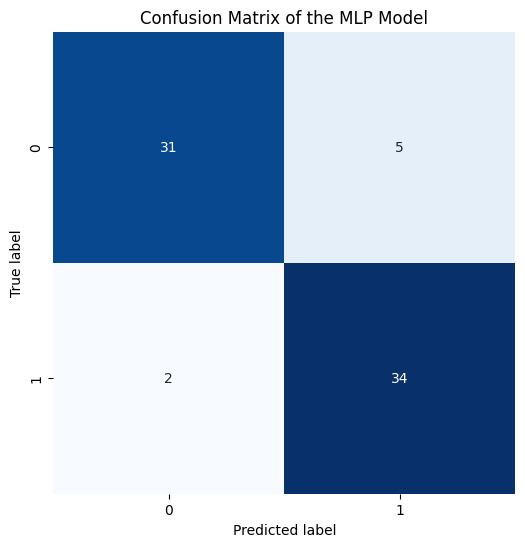

In [18]:
# Convert TestLabel and Predicted into single-column vectors for evaluations
TestLabel_rev = np.argmax(TestLabel, axis=1)
Predicted_rev = np.argmax(Predicted, axis=1)

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(TestLabel_rev, Predicted_rev)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues, cbar=False, square=True)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix of the MLP Model")
plt.show()

In [19]:
from sklearn import metrics

# Calculate the evaluation metrics
accuracy  = metrics.accuracy_score(TestLabel_rev, Predicted_rev)
precision = metrics.precision_score(TestLabel_rev, Predicted_rev)
recall    = metrics.recall_score(TestLabel_rev, Predicted_rev)
f1_score  = metrics.f1_score(TestLabel_rev, Predicted_rev)

# Print the evaluation metrics
print(f"MLP Model Evaluation:\n")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1_score:.2f}")

MLP Model Evaluation:

Accuracy : 0.90
Precision: 0.87
Recall   : 0.94
F1 Score : 0.91
